In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
df.head(5)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
#Input Feature
#AT --> Temperature
#V --> Vaccum
#AP --> Pressure
#RH --> Humidity

#Output Feature
#PE --> Produced Energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE", axis=1)  
y = df["PE"]             

In [8]:
#split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [10]:
df.shape

(9568, 5)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



In [12]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [13]:
X_test_scaled

array([[ 1.36255441,  0.24305848, -1.27798491, -1.04586379],
       [ 0.82147733,  1.36986442, -0.74695303,  0.31071896],
       [-0.247116  , -0.73708132,  1.92304887, -0.14668594],
       ...,
       [-0.67970645, -1.15815506, -0.31652036, -0.05697206],
       [ 1.33136451,  1.34463153, -0.87558808, -0.39000089],
       [-0.26474508, -0.26711887,  0.33984824,  1.14397069]],
      shape=(1914, 4))

In [14]:
import torch
import torch.nn as nn



In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype= torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype= torch.float32).view(-1,1)


In [16]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [17]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
        # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

        # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

        #Output layer
            nn.Linear(6,1),
    )

    def forward(self,x):
        return self.model(x)

In [18]:
import torch.optim as optim
model = ANN()

#loss,optimizer 

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [20]:
#Training
train_losses = []
valid_losses = []
epochs = 100
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 epoch

    for xb,yb in train_loader:
        #xb = input features of one batch
        #yb = output features of second batch
        optimizer.zero_grad()
        outputs = model(xb) #forward_prop...predicted outputs
        loss = criterion(outputs,yb) #compute loss
        loss.backward() #backward_prop ...compute_gradient
        optimizer.step() #parameter updates

        running_loss += loss.item() #loss is a tensor

    epoch_training_loss = running_loss/len(train_loader)
    train_losses.append(epoch_training_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): #no gradients compute
        for xb,yb in test_loader:
            
                outputs = model(xb) #forward_prop...predicted outputs
                loss = criterion(outputs,yb) #compute loss
                running_val_loss += loss
        
                running_loss += loss.item()

        epoch_val_loss = running_val_loss/len(test_loader)
        valid_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_training_loss:.4f} & val loss = {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss:
             best_val_loss = epoch_val_loss
             torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 ==> train loss = 205874.1917 & val loss = 204310.6406
epoch 2/100 ==> train loss = 199757.3628 & val loss = 192049.2969
epoch 3/100 ==> train loss = 178236.8972 & val loss = 161029.0938
epoch 4/100 ==> train loss = 138911.9714 & val loss = 115142.2188
epoch 5/100 ==> train loss = 91160.6420 & val loss = 68739.8906
epoch 6/100 ==> train loss = 51047.9934 & val loss = 36751.7305
epoch 7/100 ==> train loss = 28413.3595 & val loss = 22285.5449
epoch 8/100 ==> train loss = 19329.6003 & val loss = 16871.7031
epoch 9/100 ==> train loss = 15585.8425 & val loss = 14017.2510
epoch 10/100 ==> train loss = 13091.5111 & val loss = 11726.7539
epoch 11/100 ==> train loss = 10890.4273 & val loss = 9632.1963
epoch 12/100 ==> train loss = 8843.3961 & val loss = 7684.5669
epoch 13/100 ==> train loss = 6924.4032 & val loss = 5909.2021
epoch 14/100 ==> train loss = 5241.6606 & val loss = 4352.6772
epoch 15/100 ==> train loss = 3777.1599 & val loss = 3078.9448
epoch 16/100 ==> train loss = 2641.

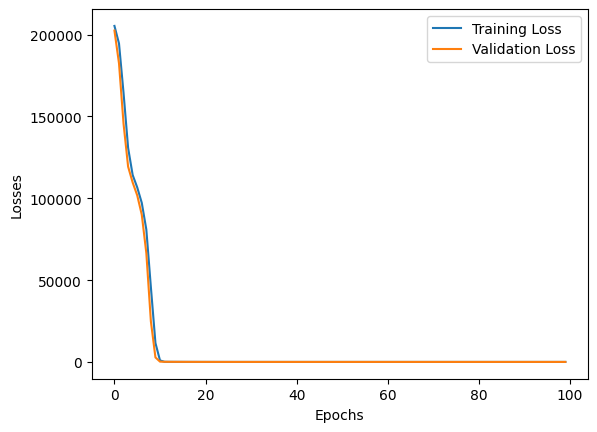

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()